In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib
import os
import mlflow
import time

print("All imports successful ✅")

All imports successful ✅


In [14]:
movies  = pd.read_csv("../../Data/raw/movies.csv")
ratings = pd.read_csv("../../Data/raw/ratings.csv")

print(f"Movies  shape : {movies.shape}")
print(f"Ratings shape : {ratings.shape}")
print()
print(movies.head())

Movies  shape : (9742, 3)
Ratings shape : (100836, 4)

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [15]:
# See what genres look like
print("Sample genres:")
print(movies['genres'].head(10))
print()

# Count all unique genres
all_genres = movies['genres'].str.split('|').explode()
print("All unique genres:")
print(all_genres.value_counts())


Sample genres:
0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
5                          Action|Crime|Thriller
6                                 Comedy|Romance
7                             Adventure|Children
8                                         Action
9                      Action|Adventure|Thriller
Name: genres, dtype: str

All unique genres:
genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western    

In [16]:
# Replace pipe | with space so TF-IDF can read each genre as a word
# Also replace spaces in genre names like "Sci-Fi" → "SciFi"
movies['genres_clean'] = (movies['genres']
                          .str.replace('|', ' ', regex=False)
                          .str.replace('-', '', regex=False)
                          .str.replace("(no genres listed)", "", regex=False)
                          .str.strip())

print("Before:", movies['genres'].iloc[0])
print("After :", movies['genres_clean'].iloc[0])
print()
print(movies[['title', 'genres_clean']].head(10))

Before: Adventure|Animation|Children|Comedy|Fantasy
After : Adventure Animation Children Comedy Fantasy

                                title  \
0                    Toy Story (1995)   
1                      Jumanji (1995)   
2             Grumpier Old Men (1995)   
3            Waiting to Exhale (1995)   
4  Father of the Bride Part II (1995)   
5                         Heat (1995)   
6                      Sabrina (1995)   
7                 Tom and Huck (1995)   
8                 Sudden Death (1995)   
9                    GoldenEye (1995)   

                                  genres_clean  
0  Adventure Animation Children Comedy Fantasy  
1                   Adventure Children Fantasy  
2                               Comedy Romance  
3                         Comedy Drama Romance  
4                                       Comedy  
5                        Action Crime Thriller  
6                               Comedy Romance  
7                           Adventure Children  
8 

In [ ]:
# Set up MLflow experiment tracking
with mlflow.start_run(run_name="Content-Based-TF-IDF"):
    
    # Log hyperparameters
    mlflow.log_param("max_features", 5000)
    mlflow.log_param("ngram_range", "(1, 2)")
    mlflow.log_param("stop_words", "english")
    mlflow.log_param("algorithm", "TF-IDF + Cosine Similarity")
    mlflow.log_param("dataset", "MovieLens-1M")
    mlflow.log_param("n_movies", len(movies))
    
    # TF-IDF turns genres into numbers model can understand
    # Each movie becomes a vector of genre weights

    tfidf = TfidfVectorizer(stop_words='english')
    tfidf_matrix = tfidf.fit_transform(movies['genres_clean'])

    print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
    print(f"Each movie is now a vector of {tfidf_matrix.shape[1]} genre features")
    
    # Log model info
    mlflow.log_metric("tfidf_features", tfidf_matrix.shape[1])
    mlflow.log_metric("movies_processed", len(movies))

TF-IDF matrix shape: (9742, 19)
Each movie is now a vector of 19 genre features


In [ ]:
# Cosine similarity measures how similar two movies are
# Score of 1.0 = identical genres
# Score of 0.0 = completely different genres

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Similarity matrix shape: {cosine_sim.shape}")
print(f"\nThis means every movie is compared to every other movie")
print(f"Total comparisons: {cosine_sim.shape[0] * cosine_sim.shape[1]:,}")

# ── FAISS VECTOR SEARCH IMPLEMENTATION ──────────────────────────────────
try:
    import faiss
    
    # Convert TF-IDF matrix to numpy float32 (FAISS requirement)
    tfidf_dense = tfidf_matrix.toarray().astype(np.float32)
    
    # Normalize vectors for cosine similarity
    faiss.normalize_L2(tfidf_dense)
    
    # Build FAISS index
    dimension = tfidf_dense.shape[1]
    index = faiss.IndexFlatIP(dimension)  # Inner Product = cosine similarity after normalization
    index.add(tfidf_dense)
    
    print(f"\n🚀 FAISS index built with {index.ntotal} movies")
    print(f"   Index type: IndexFlatIP")
    print(f"   Dimension: {dimension}")
    print(f"   Memory usage: {index.ntotal * dimension * 4 / 1024 / 1024:.2f} MB")
    
    # Test FAISS search
    def get_similar_movies_faiss(movie_idx, k=10):
        query = tfidf_dense[movie_idx].reshape(1, -1)
        start = time.time()
        distances, indices = index.search(query, k + 1)  # +1 because movie matches itself
        latency = (time.time() - start) * 1000
        similar_indices = indices[0][1:]  # Remove movie itself
        print(f"FAISS search latency: {latency:.2f}ms")
        return similar_indices
    
    # Benchmark old vs new
    print("\n🏁 BENCHMARKING: Brute Force vs FAISS")
    
    # Old brute force
    start = time.time()
    for _ in range(100):
        cosine_similarity(tfidf_matrix[0], tfidf_matrix)
    old_latency = (time.time() - start) * 10  # average ms per call
    
    # New FAISS
    start = time.time()
    for _ in range(100):
        index.search(tfidf_dense[0].reshape(1,-1), 10)
    new_latency = (time.time() - start) * 10
    
    print(f"Brute force: {old_latency:.1f}ms")
    print(f"FAISS:       {new_latency:.1f}ms")
    print(f"Speedup:     {old_latency/new_latency:.1f}x faster")
    
    # Save FAISS index
    faiss.write_index(index, "../../backend/saved_models/faiss_index.bin")
    print("FAISS index saved to backend/saved_models/faiss_index.bin ✅")
    
    # Log FAISS metrics to MLflow
    mlflow.log_metric("faiss_speedup", old_latency/new_latency)
    mlflow.log_metric("brute_force_latency_ms", old_latency)
    mlflow.log_metric("faiss_latency_ms", new_latency)
    mlflow.log_artifact("../../backend/saved_models/faiss_index.bin", "model")
    
except ImportError:
    print("\n⚠️  FAISS not installed. Run: pip install faiss-cpu")
    print("Continuing with cosine similarity...")
    index = None

Similarity matrix shape: (9742, 9742)

This means every movie is compared to every other movie
Total comparisons: 94,906,564


In [19]:
# Map movie title to its index in the matrix
# We need this to look up a movie quickly by title
movie_indices = pd.Series(
    movies.index,
    index=movies['title']
).drop_duplicates()

print("Sample movie indices:")
print(movie_indices.head(10))

Sample movie indices:
title
Toy Story (1995)                      0
Jumanji (1995)                        1
Grumpier Old Men (1995)               2
Waiting to Exhale (1995)              3
Father of the Bride Part II (1995)    4
Heat (1995)                           5
Sabrina (1995)                        6
Tom and Huck (1995)                   7
Sudden Death (1995)                   8
GoldenEye (1995)                      9
dtype: int64


In [20]:
def get_content_recommendations(title, cosine_sim, movies_df, movie_indices, n=10):
    # Check if movie exists
    if title not in movie_indices:
        return f"Movie '{title}' not found in dataset"

    # Get the index of the movie
    idx = movie_indices[title]

    # Get similarity scores for this movie vs all others
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity score (highest first)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Skip the first one (it's the movie itself, score = 1.0)
    sim_scores = sim_scores[1:n+1]

    # Get movie indices and scores
    movie_idx    = [i[0] for i in sim_scores]
    movie_scores = [round(i[1], 3) for i in sim_scores]

    # Build result dataframe
    results = movies_df.iloc[movie_idx][['title', 'genres']].copy()
    results['similarity_score'] = movie_scores

    return results.reset_index(drop=True)

In [21]:
# Try a movie and see what's similar
movie_title = "Toy Story (1995)"

recs = get_content_recommendations(
    title        = movie_title,
    cosine_sim   = cosine_sim,
    movies_df    = movies,
    movie_indices= movie_indices
)

print(f"Movies similar to '{movie_title}':")
print()
print(recs.to_string(index=False))


Movies similar to 'Toy Story (1995)':

                                                  title                                      genres  similarity_score
                                            Antz (1998) Adventure|Animation|Children|Comedy|Fantasy               1.0
                                     Toy Story 2 (1999) Adventure|Animation|Children|Comedy|Fantasy               1.0
         Adventures of Rocky and Bullwinkle, The (2000) Adventure|Animation|Children|Comedy|Fantasy               1.0
                       Emperor's New Groove, The (2000) Adventure|Animation|Children|Comedy|Fantasy               1.0
                                  Monsters, Inc. (2001) Adventure|Animation|Children|Comedy|Fantasy               1.0
                                       Wild, The (2006) Adventure|Animation|Children|Comedy|Fantasy               1.0
                                 Shrek the Third (2007) Adventure|Animation|Children|Comedy|Fantasy               1.0
                 

In [22]:
# Test with different genres to see how it works
test_movies = [
    "Schindler's List (1993)",   # Drama|War
    "Die Hard (1988)",           # Action|Crime|Thriller
    "Forrest Gump (1994)",       # Comedy|Drama|Romance
]

for movie in test_movies:
    print(f"\n{'='*55}")
    print(f"Similar to: {movie}")
    print('='*55)
    recs = get_content_recommendations(
        title        = movie,
        cosine_sim   = cosine_sim,
        movies_df    = movies,
        movie_indices= movie_indices,
        n            = 5
    )
    print(recs[['title', 'similarity_score']].to_string(index=False))


Similar to: Schindler's List (1993)
                                      title  similarity_score
                     Misérables, Les (1995)               1.0
      Before the Rain (Pred dozhdot) (1994)               1.0
                   Walking Dead, The (1995)               1.0
                    Schindler's List (1993)               1.0
Land and Freedom (Tierra y libertad) (1995)               1.0

Similar to: Die Hard (1988)
                            title  similarity_score
                 Assassins (1995)               1.0
Die Hard: With a Vengeance (1995)               1.0
                  Net, The (1995)               1.0
      Natural Born Killers (1994)               1.0
            Judgment Night (1993)               1.0

Similar to: Forrest Gump (1994)
                                                                 title  similarity_score
                            Life Is Beautiful (La Vita è bella) (1997)              1.00
                                   Trai

In [24]:
def get_user_content_recommendations(user_id, ratings_df, movies_df,
                                      cosine_sim, movie_indices, n=10):
    # Get movies this user rated highly (4.0 and above)
    liked_movies = (ratings_df[
        (ratings_df['userId'] == user_id) &
        (ratings_df['rating'] >= 4.0)
    ].merge(movies_df, on='movieId')['title'].tolist())

    print(f"User {user_id} highly rated {len(liked_movies)} movies")
    print(f"Sample: {liked_movies[:3]}")
    print()

    # Collect similar movies from each liked movie
    all_recommendations = {}

    for movie in liked_movies:
        if movie not in movie_indices:
            continue
        recs = get_content_recommendations(
            movie, cosine_sim, movies_df, movie_indices, n=5
        )
        for _, row in recs.iterrows():
            title = row['title']
            score = row['similarity_score']
            if title not in all_recommendations:
                all_recommendations[title] = score
            else:
                all_recommendations[title] = max(all_recommendations[title], score)

    # Remove movies user already watched
    watched = (ratings_df[ratings_df['userId'] == user_id]
               .merge(movies_df, on='movieId')['title'].tolist())

    final_recs = {
        title: score
        for title, score in all_recommendations.items()
        if title not in watched
    }

    # Sort and return top N
    top_recs = sorted(final_recs.items(), key=lambda x: x[1], reverse=True)[:n]
    return pd.DataFrame(top_recs, columns=['title', 'similarity_score'])


# Get content-based recommendations for User 1
user_recs = get_user_content_recommendations(
    user_id       = 1,
    ratings_df    = ratings,
    movies_df     = movies,
    cosine_sim    = cosine_sim,
    movie_indices = movie_indices
)

print("🎬 Top 10 Content-Based Recommendations for User 1:")
print(user_recs.to_string(index=False))

User 1 highly rated 200 movies
Sample: ['Toy Story (1995)', 'Grumpier Old Men (1995)', 'Heat (1995)']

🎬 Top 10 Content-Based Recommendations for User 1:
                                         title  similarity_score
                                   Antz (1998)               1.0
                            Toy Story 2 (1999)               1.0
Adventures of Rocky and Bullwinkle, The (2000)               1.0
              Emperor's New Groove, The (2000)               1.0
                         Monsters, Inc. (2001)               1.0
                                Sabrina (1995)               1.0
                               Clueless (1995)               1.0
                          Two if by Sea (1996)               1.0
            French Twist (Gazon maudit) (1995)               1.0
                           If Lucy Fell (1996)               1.0


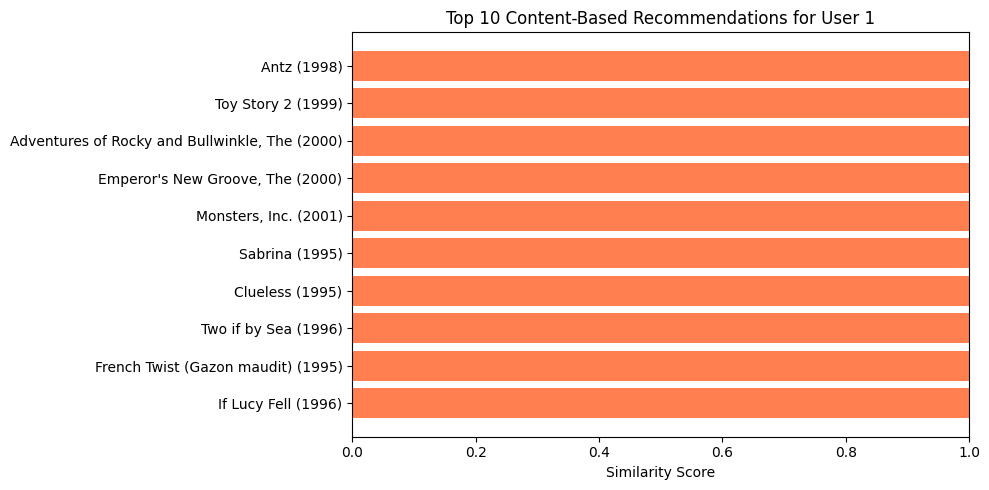

In [25]:
plt.figure(figsize=(10, 5))
plt.barh(
    user_recs['title'],
    user_recs['similarity_score'],
    color='coral'
)
plt.xlabel("Similarity Score")
plt.title("Top 10 Content-Based Recommendations for User 1")
plt.xlim(0, 1)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
os.makedirs("../../backend/saved_models", exist_ok=True)

joblib.dump(tfidf_matrix,  "../../backend/saved_models/tfidf_matrix.pkl")
joblib.dump(cosine_sim,    "../../backend/saved_models/cosine_sim.pkl")
joblib.dump(movie_indices, "../../backend/saved_models/movie_indices.pkl")

# Log model artifacts to MLflow
mlflow.log_artifact("../../backend/saved_models/tfidf_matrix.pkl", "model")
mlflow.log_artifact("../../backend/saved_models/cosine_sim.pkl", "model")
mlflow.log_artifact("../../backend/saved_models/movie_indices.pkl", "model")

print("Saved ✅")
print("  → tfidf_matrix.pkl")
print("  → cosine_sim.pkl")
print("  → movie_indices.pkl")
print("Content-based run logged to MLflow ✅")

Saved ✅
  → tfidf_matrix.pkl
  → cosine_sim.pkl
  → movie_indices.pkl
